<a href="https://colab.research.google.com/github/Bpatnaik470/Bpatnaik470/blob/main/Copy_of_Capstone_session_7_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task: Cluster the credit card users into different groups to find any meaningful patterns. Use
Principal Component Analysis (PCA) to reduce the dimension of the feature space and then
use the K-means algorithm to find clusters. Import relevant Python libraries.
• Load dataset (CC GENERAL.csv, the name of the file when downloaded from Kaggle.)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
cc_df = pd.read_csv('/content/CC GENERAL.csv')
print("Dataset Shape:", cc_df.shape)
display(cc_df.head())

Dataset Shape: (8950, 18)


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [ ]:
print("Missing values per column:")
display(cc_df.isnull().sum())

Missing values per column:


,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [ ]:
# Fill missing values with median
cc_df['CREDIT_LIMIT'] = cc_df['CREDIT_LIMIT'].fillna(cc_df['CREDIT_LIMIT'].median())
cc_df['MINIMUM_PAYMENTS'] = cc_df['MINIMUM_PAYMENTS'].fillna(cc_df['MINIMUM_PAYMENTS'].median())

# Verify no missing values remain
print('Missing values after imputation:')
print(cc_df.isnull().sum())


Missing values after imputation:
CUST_ID                             0
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64


In [ ]:
# Drop CUST_ID as it is not a numerical feature for clustering
cc_features = cc_df.drop('CUST_ID', axis=1)

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the features
cc_scaled = scaler.fit_transform(cc_features)

# Display the scaled data shape and a sample
print('Scaled Data Shape:', cc_scaled.shape)
print('\nFirst row of scaled data:')
print(cc_scaled[0])

Scaled Data Shape: (8950, 17)

First row of scaled data:
[-0.73198937 -0.24943448 -0.42489974 -0.35693402 -0.34907882 -0.46678555
 -0.80649035 -0.67866081 -0.70731317 -0.67534886 -0.47606982 -0.51133325
 -0.9603784  -0.52897879 -0.3024     -0.52555097  0.36067954]


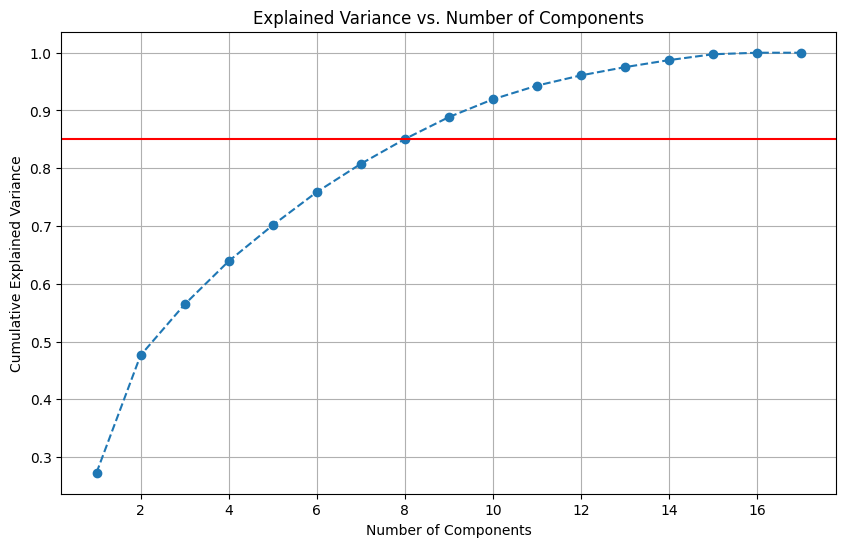

Number of components explaining 85% variance: 8


In [ ]:
pca = PCA()
pca.fit(cc_scaled)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.85, color='r', linestyle='-')
plt.title('Explained Variance vs. Number of Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid()
plt.show()

n_components_85 = np.where(cumulative_variance >= 0.85)[0][0] + 1
print(f'Number of components explaining 85% variance: {n_components_85}')

In [ ]:
# Perform PCA with 2 components
pca_2 = PCA(n_components=2)
cc_pca_2 = pca_2.fit_transform(cc_scaled)

# Create a DataFrame for visualization
pca_df = pd.DataFrame(data=cc_pca_2, columns=['Principal Component 1', 'Principal Component 2'])

print('PCA with 2 components completed.')
display(pca_df.head())

PCA with 2 components completed.


,Principal Component 1,Principal Component 2
0,-1.683649,-1.072241
1,-1.134085,2.509150
2,0.969395,-0.383577
3,-0.888220,0.004648
4,-1.600021,-0.683795


In [ ]:
# Get the loadings (components_) of the first 2 principal components
loadings = pd.DataFrame(
    pca_2.components_.T,
    columns=['PC1', 'PC2'],
    index=cc_features.columns
)

# Calculate the absolute sum of loadings to see overall importance across both components
loadings['abs_sum'] = loadings['PC1'].abs() + loadings['PC2'].abs()

# Sort by absolute sum to find top contributors
top_features = loadings.sort_values(by='abs_sum', ascending=False)

print('Top 2 features contributing most to the first two Principal Components:')
display(top_features.head(2))

print('\nFull Loadings Matrix:')
display(top_features)

Top 2 features contributing most to the first two Principal Components:


,PC1,PC2,abs_sum
PAYMENTS,0.266482,0.256716,0.523197
CASH_ADVANCE_FREQUENCY,-0.088582,0.434121,0.522703



Full Loadings Matrix:


,PC1,PC2,abs_sum
PAYMENTS,0.266482,0.256716,0.523197
CASH_ADVANCE_FREQUENCY,-0.088582,0.434121,0.522703
PURCHASES_FREQUENCY,0.321232,-0.191148,0.512380
BALANCE,0.101735,0.403819,0.505554
CASH_ADVANCE_TRX,-0.048136,0.419644,0.467779
CASH_ADVANCE,-0.022810,0.439027,0.461836
PURCHASES_INSTALLMENTS_FREQUENCY,0.274494,-0.178869,0.453363
PURCHASES,0.411562,0.040025,0.451587
CREDIT_LIMIT,0.211916,0.238028,0.449945
PURCHASES_TRX,0.390599,-0.020168,0.410767


Covariance Matrix derived from PCA:


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
BALANCE,1.000112,0.322448,0.181281,0.164368,0.126483,0.496747,-0.077952,0.073174,-0.063193,0.449268,0.385195,0.154356,0.531356,0.322838,0.397965,-0.318995,0.072700
BALANCE_FREQUENCY,0.322448,1.000112,0.133689,0.104335,0.124306,0.099399,0.229741,0.202438,0.176099,0.191894,0.141571,0.189647,0.095942,0.065015,0.131195,-0.095093,0.119789
PURCHASES,0.181281,0.133689,1.000112,0.916947,0.679972,-0.051480,0.393061,0.498485,0.315602,-0.120157,-0.067183,0.689638,0.357017,0.603331,0.095800,0.180399,0.086298
ONEOFF_PURCHASES,0.164368,0.104335,0.916947,1.000112,0.330658,-0.031329,0.264967,0.524950,0.127743,-0.082637,-0.046217,0.545584,0.319771,0.567355,0.050262,0.132778,0.064157
INSTALLMENTS_PURCHASES,0.126483,0.124306,0.679972,0.330658,1.000112,-0.064251,0.442467,0.214066,0.511408,-0.132333,-0.074007,0.628178,0.256543,0.384127,0.134034,0.182590,0.086153
CASH_ADVANCE,0.496747,0.099399,-0.051480,-0.031329,-0.064251,1.000112,-0.215531,-0.086764,-0.177090,0.628592,0.656571,-0.075859,0.304031,0.453289,0.140763,-0.152952,-0.068320
PURCHASES_FREQUENCY,-0.077952,0.229741,0.393061,0.264967,0.442467,-0.215531,1.000112,0.501399,0.863030,-0.308513,-0.203501,0.568493,0.119846,0.103476,0.006155,0.305837,0.061513
ONEOFF_PURCHASES_FREQUENCY,0.073174,0.202438,0.498485,0.524950,0.214066,-0.086764,0.501399,1.000112,0.142345,-0.111728,-0.069096,0.544930,0.295092,0.243564,-0.027314,0.157548,0.082475
PURCHASES_INSTALLMENTS_FREQUENCY,-0.063193,0.176099,0.315602,0.127743,0.511408,-0.177090,0.863030,0.142345,1.000112,-0.262988,-0.169226,0.530034,0.060801,0.085561,0.032059,0.250115,0.073284
CASH_ADVANCE_FREQUENCY,0.449268,0.191894,-0.120157,-0.082637,-0.132333,0.628592,-0.308513,-0.111728,-0.262988,1.000112,0.799650,-0.131183,0.132622,0.183212,0.100628,-0.249801,-0.133387


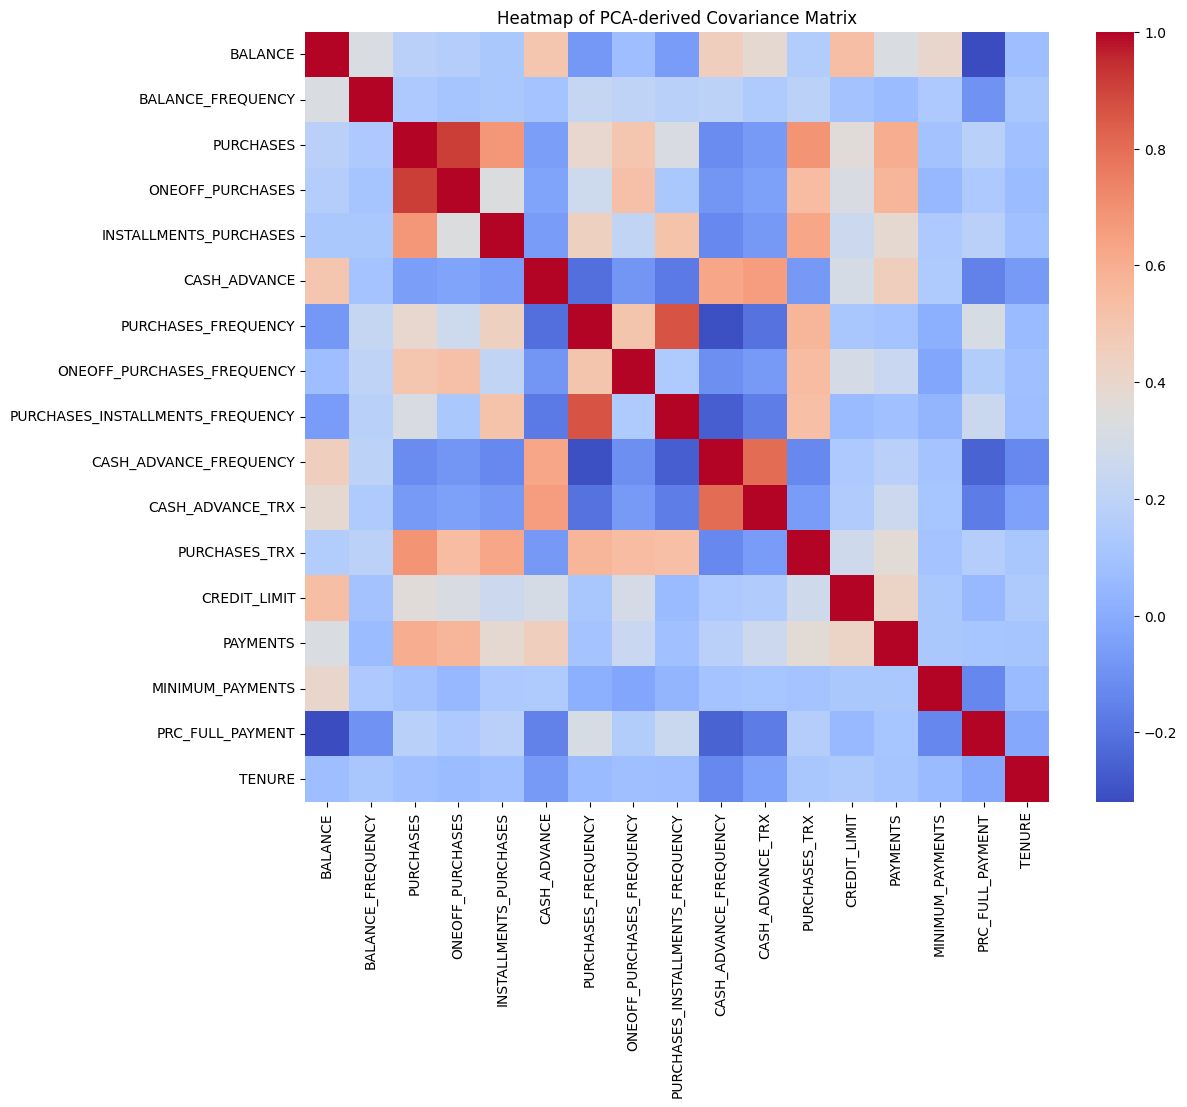

In [ ]:
# Calculate the covariance matrix using PCA's get_covariance() method
cov_matrix = pca.get_covariance()

# Create a DataFrame for better visualization
cov_df = pd.DataFrame(cov_matrix, index=cc_features.columns, columns=cc_features.columns)

print('Covariance Matrix derived from PCA:')
display(cov_df)

# Highlight high covariance pairs (excluding diagonal)
plt.figure(figsize=(12, 10))
sns.heatmap(cov_df, annot=False, cmap='coolwarm')
plt.title('Heatmap of PCA-derived Covariance Matrix')
plt.show()

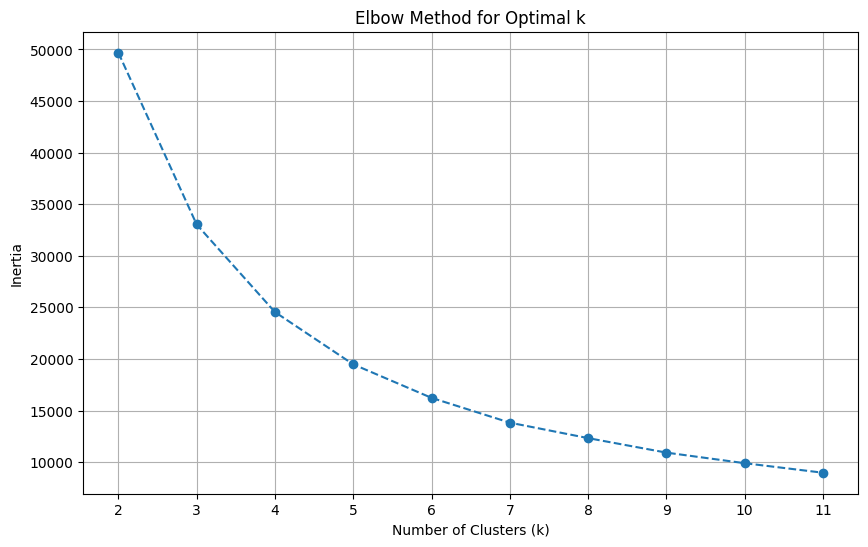

In [ ]:
inertia = []
range_clusters = range(2, 12)

for k in range_clusters:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(cc_pca_2)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(range_clusters, inertia, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(range_clusters)
plt.grid(True)
plt.show()

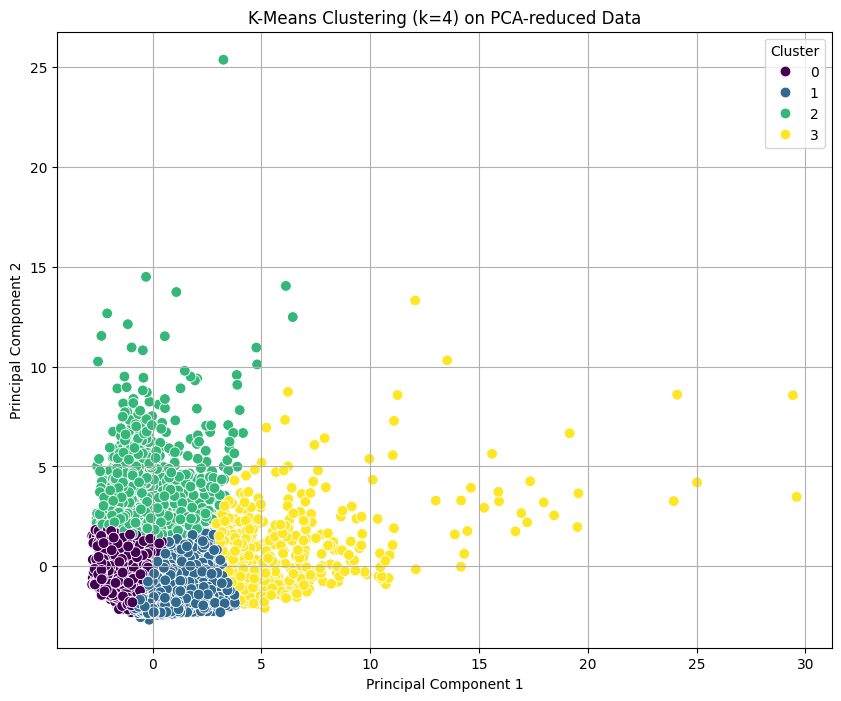

Number of users in each cluster:
Cluster
0    3918
1    3284
2    1246
3     502
Name: count, dtype: int64


In [ ]:
# Applying K-Means with the ideal number of clusters (k=4)
ideal_k = 4
kmeans_final = KMeans(n_clusters=ideal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_transform(cc_pca_2)

# Add labels to our PCA DataFrame
pca_df['Cluster'] = kmeans_final.labels_

# Visualize the clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(data=pca_df, x='Principal Component 1', y='Principal Component 2', hue='Cluster', palette='viridis', s=60)
plt.title(f'K-Means Clustering (k={ideal_k}) on PCA-reduced Data')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# Check cluster sizes
print('Number of users in each cluster:')
print(pca_df['Cluster'].value_counts())

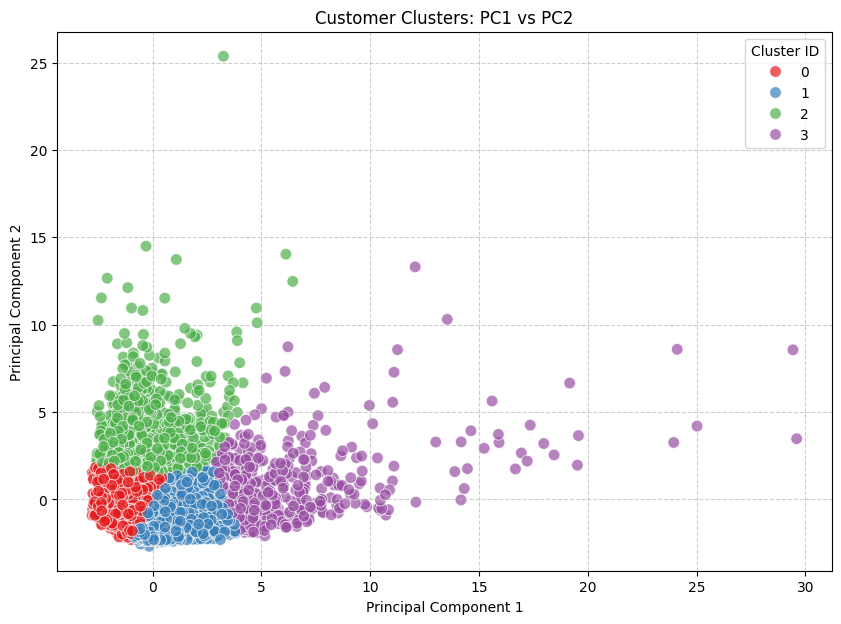

In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='Cluster', data=pca_df, palette='Set1', s=70, alpha=0.7)
plt.title('Customer Clusters: PC1 vs PC2')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster ID', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()